# **Week 7: Continuous distributions**

```
.------------------------------------.
|   __  ____  ______  _  ___ _____   |
|  |  \/  \ \/ / __ )/ |/ _ \___  |  |
|  | |\/| |\  /|  _ \| | | | | / /   |
|  | |  | |/  \| |_) | | |_| |/ /    |
|  |_|  |_/_/\_\____/|_|\___//_/     |
'------------------------------------'

```

Today's workshop is on continuous distributions. We will have a combination of pen-and-paper questions and learn how to simulate and do calculations with continuous random variables in R.

# Warm-up
Suggest the most appropriate distribution for the following situations. (Note that any distribution from Weeks 6 and 7 might be relevant here.)


a) The time needed to serve a customer at a fast food restaurant.

b) The time needed to serve a customer at a fast food restaurant after 10 minutes of not having any customers.

c) The number of probability text books you need to read until you find one with “Markov chain processes” in it.

d) The exact amount of rice in a 1kg packet from the supermarket.

e) The number of eggs in a six pack that are not broken.

f) The number of job applications you have to check until you have 5 that meet the qualifications.

g) The number of customers you serve in 1 hour at a fast food restaurant.

h) The number of tickets a ticket inspector would have to check until finding one person without a ticket.

i) The time your bus arrives, given you know it will arrive at some time between 8:00am and 8:10am.

<details>
<summary>▶️ Click to show the solution</summary>
a) Exponential

b) Exponential

c) Geometric

d) Normal

e) Binomial

f) Negative Binomial

g) Poisson

h) Geometric

i) Uniform
</details>

## **Pre-Configurating the Notebook**

### **Switching to the R Kernel on Colab**

By default, Google Colab uses Python as its programming language. To use R instead, you’ll need to manually switch the kernel by going to **Runtime > Change runtime type**, and selecting R as the kernel. This allows you to run R code in the Colab environment.

However, our notebook is already configured to use R by default. Unless something goes wrong, you shouldn’t need to manually change runtime type.

### **Importing Required Packages**
**Run the following lines of code**:

In [1]:
#Do not modify

setwd("/content")

# Remove `MXB107-Notebooks` if exists,
if (dir.exists("MXB107-Notebooks")) {
  system("rm -rf MXB107-Notebooks")
}

# Fork the repository
system("git clone https://github.com/ArwenNugteren/MXB107-Notebooks")

# Change working directory to "MXB107-Notebooks"
setwd("MXB107-Notebooks")

#
invisible(source("R/preConfigurated.R"))

Loading required package: ggplot2

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: tidyr

Loading required package: stringr

Loading required package: magrittr


Attaching package: ‘magrittr’


The following object is masked from ‘package:tidyr’:

    extract


Loading required package: IRdisplay

Loading required package: png

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘png’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: grid

Loading required package: knitr

Loading required package: jpeg

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘jpeg’”
I

**Do not modify the following**

In [2]:
if (!require("testthat")) install.packages("testthat"); library("testthat")

test_that("Test if all packages have been loaded", {

  expect_true(all(c("ggplot2", "tidyr", "dplyr", "stringr", "magrittr", "knitr") %in% loadedNamespaces()))

})

Loading required package: testthat


Attaching package: ‘testthat’


The following objects are masked from ‘package:magrittr’:

    equals, is_less_than, not




Test passed with 1 success 🥳.


# Pen-and-paper questions

## Question 1
Modern computers often generate (pseuedo) random real numbers between 0 and 1, where every number in the interval is equally likely. We model this using:
$$X \sim \text{Uniform}(0, 1)$$

a) What is the probability that the random number generated is less than 0.3?

b) If we write a program to generated 10,000 random numbers, how many would you expect to be greater than 0.9?

c) If we generate two numbers $X_1$ and $X_2$ independently, what is the probability that both are above 0.7?

<details>
<summary>▶️ Click to show the solution</summary>
Note that we have $a=0$ and $b=1$, so $Pr(X < x) = \frac{x-a}{b - a} = x$.

a) $Pr(X < 0.3) = 0.3$

b) $Pr(X > 0.9) = 1 - Pr(X < 0.9) = 1 - 0.9 = 0.1$. So, given we have 10,000 random numbers, we would expect $10,000 \times 0.1 = 1,000$ to be greater than 0.9

c) $$Pr(X_1 > 0.7) = 1 - Pr(X_1 < 0.7) = 0.3$$
$$Pr(X_2 > 0.7) = 1 - Pr(X_2 < 0.7) = 0.3$$

Using the multiplicative rule for independent random variables,
$$Pr( (X_1 > 0.7) \cap (X_2 > 0.7) ) = Pr(X_1 > 0.7) Pr(X_2 > 0.7) = 0.3 \times 0.3 = 0.09$$

</details>

## Question 2
In a game of soccer, the time between goals, $T$, has an exponential distribution with a mean of 40 minutes between goals. A game takes 90 minutes.


a) Find the probability that there is no goal in a game.

b) Calculate the lower quartile of the random variable $T$. Briefly explain in one sentence what this number tells us.

c) Determine the probability that a goal is scored in the opening 10 minutes.

d) If there is no goal in the opening 10 minutes, what is the probability that there is a goal in the opening 20 minutes?

e) In 5 soccer games, determine the probability that there is at least 1 game with no goals.

<details>
<summary>▶️ Click to show the solution</summary>
As $\mathbb{E}(T) = 40$ min, we have that $T \sim \mathrm{Exp}(1/40 = 0.025)$.


a) "No goal in a game" $= T > 90$.
				\begin{align*}
				Pr(T > 90) &= 1 - Pr(T < 90) = 1 - F(90) = 1 - (1 - e^{-0.025 \times 90}) \approx 0.105,
				\end{align*}
				where $F(t)$ is the cdf for the exponential distribution.


b) Denote $Q_1$ the lower quartile of $T$.
				\begin{align*}
				0.25 &= Pr(T < Q_1) = \int_0^{Q_1} f(t) \; dt \\
				& = \int_0^{Q_1} 0.025 e^{-0.025 t} \; dt \\
				& = \left[-e^{-0.025t}\right]_0^{Q_1} \\
				& = -e^{-0.025Q_1} + 1 \\
				\Rightarrow 0.75 &= e^{-0.025Q_1} \\
				\Rightarrow Q_1 &= \dfrac{\log(0.75)}{-0.025} \approx 11.51.
				\end{align*}

This means that, on average, in 25\% of all games a goal is scored within the first 11.51 minutes.


c) $Pr(T < 10) = F(10) = 1 - e^{-0.025\times 10} \approx 0.2212.$


d)
				\begin{align*}
				Pr(T < 20 | T > 10) &= 1 - Pr(T > 20| T > 10), & \text{complement rule}\\
				&= 1 - Pr(T > 10), & \text{Memoryless property}\\
				&= Pr(T < 10), 		& \text{complement rule} \\
				&\approx 0.2212.
				\end{align*}


e) Let $G$ be the number of games (out of 5) where there are no goals. Then (using our solution to (a)) $G \sim \mathrm{Bin}(5,0.105)$.
				\begin{align*}
				Pr(G \ge 1) = 1 - Pr(G = 0) = 1 - \binom{5}{0} 0.105^0 (1 - 0.105)^5 \approx 0.4257.
				\end{align*}
</details>

## Question 3
From the records of a pizza delivery company, 20\% of pizza orders are completed (that is, made and delivered) in under 20 minutes, and 10\% of pizzas take more than 35 minutes to make and deliver. Assuming that the time to complete a pizza order is normally distributed, obtain the expected time to complete an order and the standard deviation of the time to complete an order.

<details>
<summary>▶️ Click to show the solution</summary>

Let $T$ be the time to complete a pizza order. Let $T \sim N(\mu,\sigma^2)$.

\begin{align*}
			0.2 &= Pr(T < 20),\\
			&= Pr(Z < z_1),\quad z_1 = \dfrac{20 - \mu}{\sigma},\\
			\Rightarrow 0.2 &= Pr(Z > -z_1)
			\end{align*}
Using R:
```r
				> qnorm(0.2,0,1)
				[1] -0.8416212
```
So $z_1 \approx -0.8416$.

\begin{align*}
			0.1 &= Pr(T > 35),\\
			&= Pr(Z > z_2),\quad z_2 = \dfrac{35 - \mu}{\sigma}
			\end{align*}
Using R:
```r
				> qnorm(0.1,0,1,lower.tail = FALSE)
				[1] 1.281552
```
So, $z_2 \approx 1.2816$.

We can now solve for $\mu$ and $\sigma$ simultaneously:
			\begin{align*}
			-0.8416 &= \dfrac{20 - \mu}{\sigma},\\
			\Rightarrow \mu &= 20 + 0.8416\sigma.\\
			1.2816 &= \dfrac{35 - \mu}{\sigma},\\
			\Rightarrow \mu &= 35 - 1.2816\sigma.\\
			\therefore 35 - 1.2816\sigma &= 20 + 0.8416\sigma,\\
			\therefore \sigma &= \dfrac{35 - 20}{0.8416 + 1.2816} \approx 7.0648.\\
			\therefore \mu & \approx 20 + 0.8416 \times 7.0648 \approx 25.9457.
			\end{align*}
			Therefore, $\mu \approx 25.9457$ mins and $\sigma \approx 7.0648$ mins

</details>

# R coding questions

## Uniform Random Variables

#### **R Quick Reference**

`R` supports the following functions for computing distributional quantities and simulating from uniform distributions:

- `dunif(x, min = a, max = b)`: computes PDF of `Unif(a,b)` at `x`  
- `punif(q, min = a, max = b, lower.tail = TRUE)`: computes CDF of `Unif(a,b)` at `q`  
- `qunif(p, min = a, max = b, lower.tail = TRUE)`:  computes `p`-quantile of `Unif(a,b)`
- `runif(n, min = a, max = b)`: simulate `n` random numbers from `Unif(a,b)`

Here:

- `x`, `q`: point(s) to evaluate PDF/CDF or quantile  
- `n`: number of random numbers to simulate  
- `min`, `max`: lower and upper bounds of the uniform interval  (By default, `min = 0` and `max = 1`)
- `lower.tail`: If `TRUE`, return $\Pr(X \leq x)$ where $X \sim \text{Unif(a,b)}$. If `FALSE`, return $\Pr(X > x)$.

**However, the equality sign does NOT matter here as** $\Pr(X = x) = 0$ as $X$ is a continuous r.v.



### Exercise
An indecisive student constructs a spinner to help them decide what to do this evening. They shade different proportions of the spinner surface based on their relative importance.  

| Activity | Angle (degrees) |
|----------|------------------|
| Study    | 90°              |
| Nap     | 60°              |
| Friends    | 75°              |
| Game     | 45°              |
| Eat      | 90°              |
| **Total**| **360°**         |

Assuming that when the student spins the spinner, it has an equal likelihood of stopping anywhere on the circle.

a) What distribution can we use to model this scenario? Can you simulate 1000 spins of the spinner in R?

b) Use R to calculate the probability that the student chooses to study.

c) Use R to calculate the probability that the student either hangs out with friends, or games.

d) Use R to estimate the number of times a student will choose to eat in 100 spins. How does this value compare to the theoretical expected value of selecting 'Eat' in 100 spins?

In [16]:
spins = runif(1000,min=0,max=360)
study = sum(spins < 90)/1000
print(study)
friends = sum(spins >150 & spins < 225)/1000
games = sum(spins > 225 & spins < 270)/1000
FrNGa = friends + games
print(FrNGa)
spins2 = runif(100,min=0,max=360)
eats = sum(spins2 > 270 & spins2<360)/100
print(eats)
## Binomial Dist. , Expected value = n*p, 100*90/360 = 0.25

[1] 0.235
[1] 0.33
[1] 0.18


<details>
<summary>▶️ Click to show the solution</summary>

We can consider this to be a $\text{Uniform}(0,360)$ distribution by defining the intervals anticlockwise:
- Study: [0, 90)
- Nap: [90, 150)
- Friends: [150, 225)
- Game: [225, 270)
- Eat: [270, 360)

We can simulate 1000 spins in R using `runif()`.
```r
spins <- runif(1000, min=0, max=360)
```

b) We can sum up all the times where the simulated spins landed in the interval [0,90).
```r
prob_study <- sum(spins < 90)/1000
print(prob_study)
# answer should be close to 0.25
```

c) We use the intervals defined above (we could also do this in a single line).
```r
prob_friends <- sum(spins >= 150 & spins < 225)/1000
prob_game <- sum(spins >= 225 & spins < 270)/1000
print(prob_friends + prob_game)
```

d)
```r
spins_eat <- runif(100, min=0, max=360)
eat <- sum(spins_eat >= 270 & spins_eat < 360)
print(eat)
```
The theoretical expected count is $100 \times \frac{90}{360} = 25$. Is your value close to this? What happens if you run your code several more times?

</details>


## Exponential Distribution

#### **R Quick Reference**


`R` supports the following functions for computing distributional quantities and simulating from exponential distributions:

- `dexp(x, rate, log = FALSE)` – **compute** the PDF of `Exp(rate)`  
- `pexp(q, rate, lower.tail = TRUE, log.p = FALSE)` – **compute** the CDF of `Exp(rate)`  
- `qexp(p, rate, lower.tail = TRUE, log.p = FALSE)` – **compute** the quantile (inverse CDF) of `Exp(rate)`  
- `rexp(n, rate)` – **simulate** `n` random numbers from `Exp(rate)`

Here:

- `x`, `q`: Value(s) at which PDF or CDF is evaluated  
- `rate`: Rate parameter $\eta$ of the exponential distribution  
- `p`: Probability for the quantile function  
- `lower.tail`: If TRUE, returns P(X ≤ x); if FALSE, returns P(X > x)  


#### **Exercises**


##### **Exercise 1**


In a hypothetical scenario, the wait time for the CityDog ferry follows an exponential distribution with a mean of 15 minutes.  

Compute the probability that a passenger’s wait time for the CityDog ferry is between 10 and 20 minutes.


In [18]:
rate = 1/15 # 1 per every 15 minutes, therefore 1/15 chance per minute
#Pr(10 <= x <= 20) F(20)-F(10)
exp(-1/15*10) - exp(-1/15*20)

[1] 0.24982



<details>
<summary>▶️ Click to show the solution</summary>

Let $X$ be the waiting time for the ferry.

The mean wait time is 15 minutes, so the rate parameter is:

$$
\eta = \frac{1}{\text{mean}} = \frac{1}{15}.
$$

Thus $X \sim \text{Exponential}(1/15)$. We want to compute:

$$
\begin{align}
P(10 \le X \le 20) &= F_X(20) - F_X(10) \\ &= \left(1 - e^{-\eta \cdot 20}\right) - \left(1 - e^{-\eta \cdot 10}\right) \\&= e^{-\eta \cdot 10} - e^{-\eta \cdot 20}.
\end{align}
$$

The two solutions are equivalent:

```r
exp(-1/15*10) - exp(-1/15*20)
```

```r
pexp(20, rate = 1/15) - pexp(10, rate = 1/15)
```


</details>


##### **Exercise 2**

Using the `rexp()` function, simulate 1000 random wait times for passengers of the CityDog ferry. Visualise the simulated distribution using a histogram. Is it realistic?

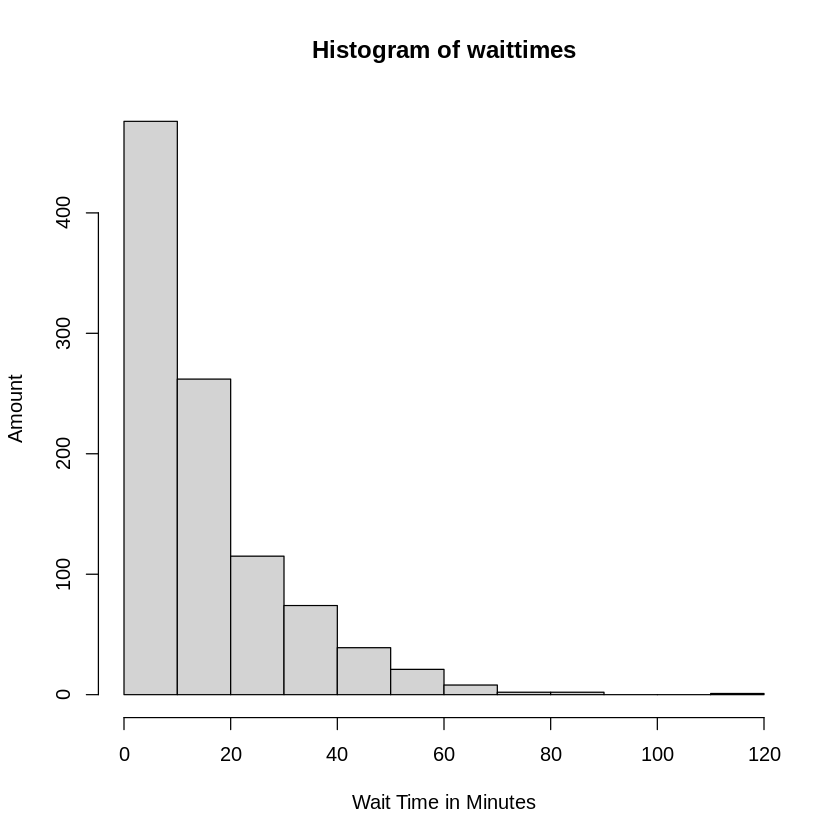

In [25]:
waittimes = rexp(1000, 1/15)
hist(waittimes, xlab = "Wait Time in Minutes", ylab = "Amount")
#Not realistic, wait time is way over into the 100's



<details>
<summary>▶️ Click to show the solution</summary>


```r
n <- 1000
times <- rexp(n, 1/15)
hist(times)
```

The exponential distribution assumption is probably not reasonable, since from the histogram we can see that the exponential distribution can generate some very large wait times (greater than 100 minutes).  The memoryless assumption of wait times for the ferry is unlikely to hold, and it might be better to model wait times with another distribution.

</details>


##### **Exercise 3**


Suppose the waiting time (in hours) for a customer service call follows $X \sim \text{Exponential}(0.5)$.  Compute the probability that a customer waits more than 3 hours given that they have already waited 2 hours.  

In [28]:
rate = 0.5 #per hour
#Pr(T>3|T>2) = Pr(3-2) = Pr(1) -Memory Loss Property
pexp(q = 1, rate, lower.tail = FALSE)

[1] 0.6065307



<details>
<summary>▶️ Click to show the solution</summary>

Given $X \sim \text{Exp(0.5)}$, to calculate $\Pr(X > 3| X > 2)$, we can use the conditional probability formula:

$$
\Pr(X > 3| X > 2) =  \frac{\Pr(X > 3 \text{ and } X > 2)}{\Pr(X > 2)} = \frac{\Pr(X > 3)}{\Pr(X > 2)}.
$$

```r
pexp(q = 3, rate = 0.5, lower.tail = FALSE)/pexp(q = 2, rate = 0.5, lower.tail = FALSE)
```
However, as $X$ follows a exponential distribution, because of the memoryless property of exponential distributions, the probability that a customer waits more than a certain additional time does not depend on how long they have already been waiting.  Then,

$$
\Pr(X > 3| X > 2) = \Pr(X > (3-2)) = \Pr(X > 1).
$$

```r
pexp(q = 1, rate = 0.5, lower.tail = FALSE)
```

It's pretty clear that this is an overly simplistic model for waiting times, as we'd expect that another ferry would come along before we waited 3 hours for the original one.

</details>


## Gaussian (Normal) Distribution


#### **R Quick Reference**

`R` supports the following functions for computing distributional quantities and simulating from Gaussian distributions (**note that R accepts the standard deviation as a parameter, not the variance**):


- `dnorm(x, mean, sd, log=FALSE)`: computes PDF of `N(mean, sd)` at $x$.
- `pnorm(q, mean, sd, lower.tail=TRUE, log.p=FALSE)`: computes CDF of `N(mean, sd)` at $q$
- `qnorm(p, mean, sd, lower.tail=TRUE, log.p=FALSE)`: `p`-quantile of `N(mean, sd)`
- `rnorm(n, mean, sd)`: simulate `n` random numbers from `N(mean, sd)`


##### **Example**

Suppose $X \sim \mathcal{N}(100, 15^2)$. What is $\Pr(X \leq 120)$? Calculate this in R using standardisation to the standard normal distribution and using `pnorm()` directly with the given mean and standard deviation.

In [29]:
pnorm(q = 120, mean = 100, sd = 15)

[1] 0.9087888


<details>
<summary>▶️ Click to show the solution</summary>

\begin{align}
  \Pr(X \leq 120) &= \Pr(\frac{X - 100}{15} \leq \frac{120 - 100}{15}) \\
  &= \Pr(Z \leq \frac{4}{3})
\end{align}

```r
#By default, pnorm() uses mean = 0 and sd = 1, i.e., standard Gaussian
pnorm(4/3)

pnorm(120, mean=100, sd=15)
```

</details>

#### **Exercise**

##### **Exercise 1**


The weight of a 500 g package of mince follows a Gaussian probability distribution with a mean of 500 g and a standard deviation of 50 g. Write R code to compute the probability that a randomly selected package of mince will weigh:

- More than 525 g
- Less that 450 g
- Between 490 g and 510 g



<details>
<summary>▶️ Click to show the solution</summary>


```r
print("Pr(More than 525 g)")
pnorm(525, mean = 500, sd = 50, lower.tail = F)
print("Pr(Less that 450 g)")
pnorm(450, mean = 500, sd = 50, lower.tail = T)
print("Pr(Between 490 g and 510 g)")
pnorm(510, mean = 500, sd = 50, lower.tail = T) - pnorm(490, mean = 500, sd = 50, lower.tail = T)
```

</details>


##### **Exercise 2**

Let  
$$
X \sim \mathcal{N}(5,\,2^2),
$$
and define the linear transformation
$$
Y = 3X - 2.
$$

a) Derive the distribution of $Y$ by hand.

b) Compute $\Pr(Y > 10)$ using R.

c) Find the *90th percentile* of $Y$.

d) Simulate `n=1000` draws from $Y$ and plot them in a histogram.





<details>
<summary>▶️ Click to show the solution</summary>

a) Distribution of $Y$
   $$
   X \sim \mathcal{N}(5,\,4),\quad Y = 3X - 2
   $$
   $$
   \mu_Y = 3\cdot 5 - 2 = 13,\qquad \sigma_Y^2 = 3^2 \cdot 4 = 36
   $$
   $$
   \boxed{\,Y \sim \mathcal{N}(13,\,36)\,}
   $$


b) $\Pr(Y > 10)$

We can compute this probability using the `pnorm()` function.
```r
pnorm(10, mean = 13, sd = 6, lower.tail = FALSE)
# 0.6914625
```

Another option is to use normalisation.

$$z = \frac{10 - 13}{6} = -0.5$$

Look up for $z = -0.5$, we have $\Pr(Z \leq -0.5) = 0.3085$ using `1 - pnorm(-0.5)`. As a result,

$$\begin{align}
\Pr(Y > 10) &= \Pr(Z > -0.5) \\
&= 1 - \Pr(Z \leq -0.5)\\
&= 1 - 0.3085 \\
&= 0.6915
\end{align}$$



c) 90th percentile of $Y$

```r
qnorm(0.9, mean = 13, sd = 6)
```

d) Simulate `n=1000` random numbers from $Y$

```r
n = 1000
sim <- rnorm(n, mean = 13, sd = 6)
hist(sim)
```

</details>



# Workshop questions

## Question 1
Your bus to work leaves every hour. You arrive at the bus station at a random time.


a) What is the probability you will have to wait more than 15 minutes for the bus?

b) What is the probability you will have to wait between 5 and 15 minutes for the bus?

c) What is the expected time you'll have to wait for the bus?



<details>
<summary>▶️ Click to show the solution</summary>

Solutions will be released at the end of the week!

</details>


## Question 2
The time taken to complete a computer job is exponentially distributed, independently of other jobs, with, on average, 2.3 completed per minute. Find the probability that:


a) Completing a job takes less than a minute.

b) Out of 10 (independent) jobs, at least eight take less than a minute to complete.



<details>
<summary>▶️ Click to show the solution</summary>

Solutions will be released at the end of the week!

</details>


## Question 3
Let $X$ be a normally distributed random variable with a mean of 5 and a standard deviation of 10. Find:


a) $Pr(X > 10)$

b) $Pr(-20 < X < 10)$

c) $x$, such that $Pr(X > x) = 0.05$



<details>
<summary>▶️ Click to show the solution</summary>

Solutions will be released at the end of the week!

</details>


## Question 4
A manufacturer of squash racquets has collected information on time in months to breakage for their racquets in normal play, that is, not due to mishandling. Data from past records on breakages suggest an average of 17.5 months and a standard deviation of 6.2 months. The manufacturer offers a guarantee period in which racquets breaking in normal playing conditions are replaced. What guarantee period should be set if it is desired to limit the probability of replacing a racquet, to 0.01?  Assume normality for time to breakage.



<details>
<summary>▶️ Click to show the solution</summary>

Solutions will be released at the end of the week!

</details>


## Question 5

A factory produces metal rods that are supposed to have a length of 50 cm. Due to variations in the manufacturing process, the actual lengths of the rods are modeled as independent random variables:

$$
L_i \sim \mathcal{N}(\mu = 50, \sigma = 0.2), \quad i = 1, 2, \dots, n
$$

where $\mu$ is the target length in cm, and $\sigma$ is the standard deviation of the manufacturing process.

The company performs a quality control test every day, sampling **100 rods**.


#### **Question 5.1**

Rods are considered **out of specification** if their length is less than 49.6 cm or greater than 50.4 cm. Compute the probability that a single rod is out of specification.





<details>
<summary>▶️ Click to show the solution</summary>

Solutions will be released at the end of the week!

</details>


#### **Question 5.2**

For many probability distributions, their CDFs are not available in closed-form. One can try a stochastic (simulation-based) technique to estimate quantities like:

-  What is the probability that a single rod is out of specification?
- Among rods whose lengths are greater than 50.2 cm, what is the probability that their length is also greater than 50.4 cm?

Estimate the probabilities above using simulation. Compare these estimates to the exact values.




<details>
<summary>▶️ Click to show the solution</summary>

Solutions will be released at the end of the week!

</details>


#### **Question 5.3**

Let $Y$ be the number  of out-of-specification rods out of 100 sampled rods. What is the distribution of `Y`? What is the average number of out-of-specification rods?



<details>
<summary>▶️ Click to show the solution</summary>

Solutions will be released at the end of the week!

</details>


## Bonus question - Inverse transform sampling

Let $X$ be a continuous random variable with cumulative distribution function (CDF) $F_X(x)$, which is strictly increasing on its support.  Our goal is to generate random samples according to the distribution of $X$ using uniform random numbers.  

The following algorithm called inverse transform sampling can be used to simulate random numbers from $X$:

1. Generate $U \sim \text{Uniform}(0,1)$.  
2. Compute $X = F_X^{-1}(U)$, where $F_X^{-1}$ is the inverse of the CDF.  


By construction, $P(X \le x) = P(F_X^{-1}(U) \le x) = P(U \le F_X(x)) = F_X(x)$.  

Thus, $X$ generated this way has the desired distribution with CDF $F_X(x)$.  

##### **Relationship Between CDF and Quantile Function**

For a continuous random variable $X$ with positive PDF everywhere on its support:

- The CDF is $F_X(x) = P(X \le x)$  
- The **quantile function** (inverse CDF) is $F_X^{-1}(p)$, which returns the value $x$ such that $P(X \le x) = p$  

In other words, for these continuous distributions, the quantile function and the CDF are inverses of each other:

$$
F_X(F_X^{-1}(p)) = p, \quad F_X^{-1}(F_X(x)) = x
$$

This implies that we can use functions like `qunif`, `qnorm`, and `qexp` to compute inverse CDF.

#### **Exercise**

The exponential distribution `Exp(1)` has the CDF:

$$
F_X(x) = \Pr(X \leq x) = 1 - e^{-x}, \, x \geq 0.
$$

- Use the inverse transform sampling method to simulate `n=10000` random numbers from `Exp(1)`.
- In `R`, we can simulate `n` random numbers from `Exp(1)` using `rexp(n)`. Simulate `n=10000` random numbers from `Exp(1)` then compare the two simulated distributions using side-by-side histograms.




<details>
<summary>▶️ Click to show the solution</summary>

Solutions will be released at the end of the week!

</details>
